# 🎲 Sixteen-face die: fair outcomes from biased rolls

This notebook tests fair, minimally biased, and highly biased 16-face dice. It shows the uncorrected physical-face distribution, the corrected highest-slot distribution, and the physical launch cost at every bias level.

**Procedure:** roll the die 16 times. Keep the position of the unique highest face; reject and repeat when the highest face is tied. Conditional on acceptance, every one of the 16 positions is equally likely.

In [1]:
import random
import matplotlib.pyplot as plt
import numpy as np

FACE_COUNT = 16
# Lower trial count keeps the high-bias case convenient: it needs many retries.
NUM_RUNS, TRIALS = 10, 2_000
DICE = {'Fair': [1/16]*16, 'Minimal bias': [.06]*15 + [.10], 'High bias': [.75/15]*15 + [.25]}
FACES = np.arange(1, FACE_COUNT + 1)
IDEAL = 1 / FACE_COUNT

## Simulation code

Raw samples are individual physical rolls. Extracted samples are positions returned only after a unique maximum. The recorded physical-roll count includes all rejected 16-roll blocks.

In [2]:
def roll(weights): return random.choices(FACES, weights=weights, k=1)[0]

def extract(weights):
    used = 0
    while True:
        sequence = [roll(weights) for _ in FACES]; used += FACE_COUNT
        top = max(sequence)
        if sequence.count(top) == 1: return sequence.index(top) + 1, used

def probs(values): return np.bincount(values, minlength=FACE_COUNT + 1)[1:] / len(values)

def experiment(weights):
    raw_runs, fixed_runs, roll_runs = [], [], []
    for _ in range(NUM_RUNS):
        raw = [roll(weights) for _ in range(TRIALS)]
        fixed, used = zip(*[extract(weights) for _ in range(TRIALS)])
        raw_runs.append(probs(raw)); fixed_runs.append(probs(fixed)); roll_runs.append(np.mean(used))
    return np.array(raw_runs), np.array(fixed_runs), np.array(roll_runs)

results = {name: experiment(weights) for name, weights in DICE.items()}

## Uniformity and efficiency results

TV distance is the distance from uniform; zero is ideal. The table also answers how many launches are needed: `Rolls/outcome` is the average physical die rolls for one uniform result, and `Accepted blocks` is the fraction of sixteen-roll blocks that succeed.

In [3]:
summary = []
for name, (raw, fixed, rolls) in results.items():
    raw_tv = np.abs(raw.mean(0)-IDEAL).sum()/2; fixed_tv = np.abs(fixed.mean(0)-IDEAL).sum()/2
    average_rolls=rolls.mean(); summary.append((name,raw_tv,fixed_tv,average_rolls,FACE_COUNT/average_rolls))
print(f"{'Bias':<14} {'Raw TV':>8} {'Fixed TV':>9} {'Rolls/outcome':>15} {'Accepted blocks':>16}")
for name,raw_tv,fixed_tv,average_rolls,accepted in summary:
    print(f"{name:<14} {raw_tv:>8.4f} {fixed_tv:>9.4f} {average_rolls:>15.2f} {accepted:>15.1%}")

Bias             Raw TV  Fixed TV   Rolls/outcome  Accepted blocks
Fair             0.0096    0.0083           27.55           58.1%
Minimal bias     0.0406    0.0090           37.13           43.1%
High bias        0.1894    0.0089          271.99            5.9%


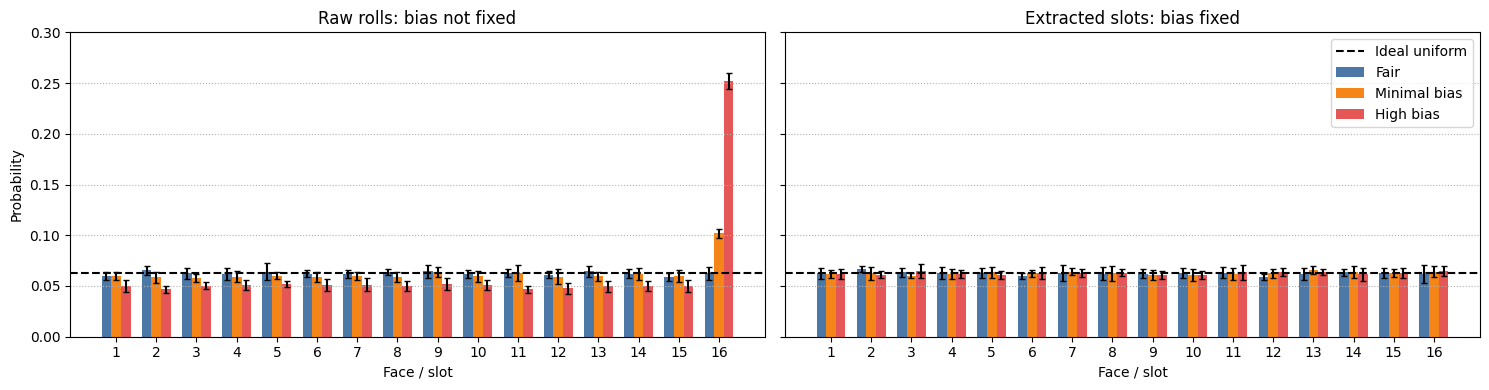

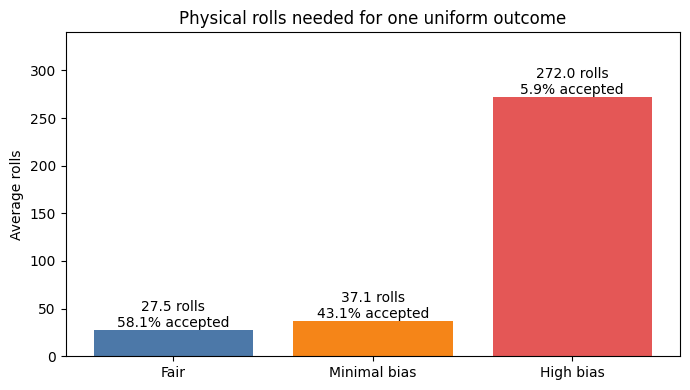

In [4]:
fig,axes=plt.subplots(1,2,figsize=(15,4),sharey=True)
colors=['#4c78a8','#f58518','#e45756']; width=.24
for ax,index,title in [(axes[0],0,'Raw rolls: bias not fixed'),(axes[1],1,'Extracted slots: bias fixed')]:
    for (name,data),offset,color in zip(results.items(),[-width,0,width],colors):
        runs=data[index]; ax.bar(FACES+offset,runs.mean(0),width,yerr=runs.std(0),capsize=2,label=name,color=color)
    ax.axhline(IDEAL,color='black',linestyle='--',label='Ideal uniform'); ax.set(title=title,xlabel='Face / slot',xticks=FACES,ylim=(0,.3)); ax.grid(axis='y',linestyle=':')
axes[0].set_ylabel('Probability'); axes[1].legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,4)); bars=plt.bar([x[0] for x in summary],[x[3] for x in summary],color=colors)
plt.title('Physical rolls needed for one uniform outcome'); plt.ylabel('Average rolls')
for bar,item in zip(bars,summary): plt.text(bar.get_x()+bar.get_width()/2,bar.get_height(),f'{item[3]:.1f} rolls\n{item[4]:.1%} accepted',ha='center',va='bottom')
plt.ylim(0,max(x[3] for x in summary)*1.25); plt.tight_layout(); plt.show()

Bias            Raw entropy  Extracted entropy
Fair                3.9950 bits          3.9943 bits
Minimal bias        3.9781 bits          3.9950 bits
High bias           3.7307 bits          3.9953 bits


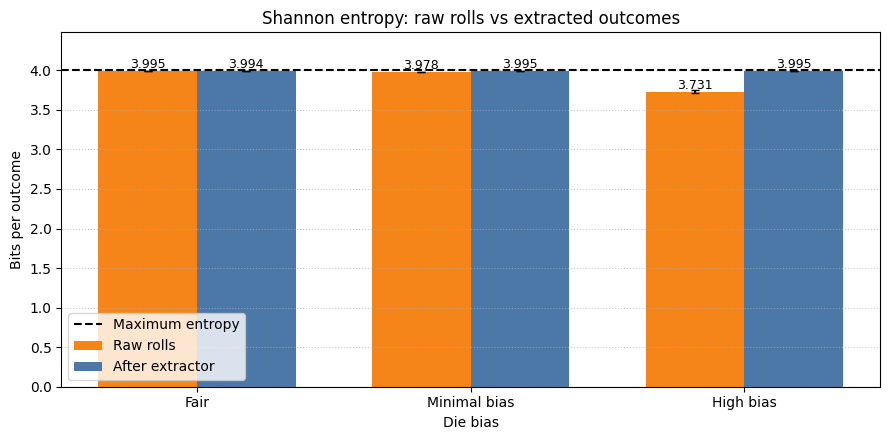

In [5]:
# Shannon entropy is calculated separately for every simulation run.
def shannon_entropy(probabilities):
    probabilities = probabilities[probabilities > 0]
    return -np.sum(probabilities * np.log2(probabilities))

entropy_summary = []
for name, (raw_runs, extracted_runs, _) in results.items():
    raw_entropy = np.array([shannon_entropy(probabilities) for probabilities in raw_runs])
    extracted_entropy = np.array([shannon_entropy(probabilities) for probabilities in extracted_runs])
    entropy_summary.append((name, raw_entropy.mean(), extracted_entropy.mean(), raw_entropy.std(), extracted_entropy.std()))

print(f"{'Bias':<14} {'Raw entropy':>12} {'Extracted entropy':>18}")
for name, raw_entropy, extracted_entropy, _, _ in entropy_summary:
    print(f"{name:<14} {raw_entropy:>11.4f} bits {extracted_entropy:>15.4f} bits")

positions = np.arange(len(entropy_summary)); width = 0.36
fig, axis = plt.subplots(figsize=(9, 4.5))
raw_bars = axis.bar(positions - width / 2, [row[1] for row in entropy_summary], width, yerr=[row[3] for row in entropy_summary], capsize=3, label='Raw rolls', color='#f58518')
extracted_bars = axis.bar(positions + width / 2, [row[2] for row in entropy_summary], width, yerr=[row[4] for row in entropy_summary], capsize=3, label='After extractor', color='#4c78a8')
maximum_entropy = np.log2(len(FACES))
axis.axhline(maximum_entropy, color='black', linestyle='--', label='Maximum entropy')
axis.set(title='Shannon entropy: raw rolls vs extracted outcomes', xlabel='Die bias', ylabel='Bits per outcome', xticks=positions, xticklabels=[row[0] for row in entropy_summary], ylim=(0, maximum_entropy * 1.12))
axis.grid(axis='y', linestyle=':', alpha=0.6); axis.legend()
for bars in (raw_bars, extracted_bars):
    for bar in bars:
        axis.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()